<a href="https://colab.research.google.com/github/Miguelangel2425/Estancia-de-investigaci-n/blob/main/CelsiusFarenheit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aquí se presenta un modelo de regresión lineal mediante redes neuronales. El objetivo es comprender cómo una arquitectura sencilla puede deducir leyes físicas a partir de ejemplos numéricos.


La relación física exacta entre la escala Celsius ($C$) y la escala Fahrenheit ($F$) es una función lineal conocida:$$F = 1.8 \cdot C + 32$$En esta ecuación, 1.8 representa la tasa de cambio (pendiente) y 32 es el punto de congelación del agua en la escala Fahrenheit (ordenada en el origen).

A diferencia de un programa tradicional donde escribiríamos la fórmula manualmente, aquí entrenaremos una red neuronal con una única neurona. Al proporcionarle pares de datos $(C, F)$, la red utilizará el algoritmo de descenso de gradiente para ajustar sus parámetros internos (pesos y sesgos) hasta "descubrir" por sí misma la relación física. Este ejercicio sirve como base conceptual antes de abordar problemas más complejos, como la resolución de ecuaciones diferenciales mediante PINNs.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Comenzando entrenamiento...
Modelo entrenado!


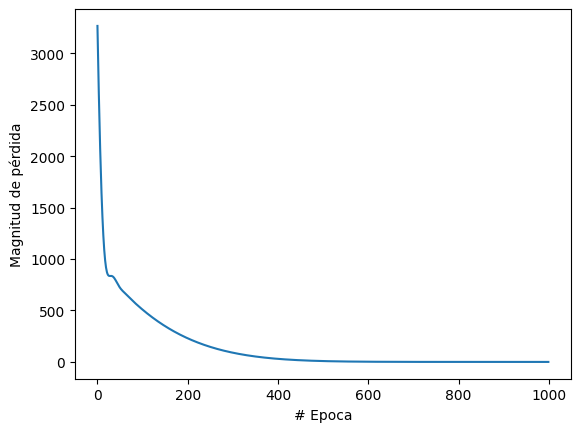

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

celsius = np.array([-40,-10,0,8,15,22,38],dtype=float)
fahrenheit = np.array([-40,14,32,46,59,72,100],dtype=float)


capa = tf.keras.layers.Dense(units=1,input_shape=[1])
modelo=tf.keras.Sequential([capa])

modelo.compile(optimizer=tf.keras.optimizers.Adam(0.1),loss='mean_squared_error')

print('Comenzando entrenamiento...')
historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=False)
print('Modelo entrenado!')

plt.xlabel('# Epoca')
plt.ylabel('Magnitud de pérdida')
plt.plot(historial.history['loss'])

Podemos probar ahora a hacer alguna predicción o podemos observar el estado en el que han quedado los parámetros internos de la red:

In [2]:
resultado = modelo.predict(np.array([100.0]))
print('El resultado es'+str(resultado))

print('Variables internas del modelo')
print(capa.get_weights())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
El resultado es[[211.74306]]
Variables internas del modelo
[array([[1.798207]], dtype=float32), array([31.922342], dtype=float32)]


La predicción para C=100 nos da F=211.74 cuando, utilizando la relación conocida $$F=1.8C + 32$$ obtenemos que da F=212, por lo que la predicción es bastante buena. Además, viendo los valores de las variables internas vemos que se obtiene $w=1.7982$ y $b=31.9223$ lo cual es muy preciso.

Finalmente, podemos probar a añadir alguna capa de neuronas más para observar qué ocurre.

Comenzando entrenamiento...
Modelo entrenado!


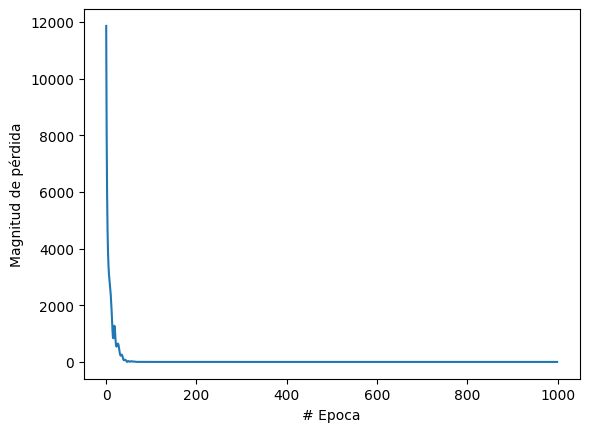

In [3]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)


print("Comenzando entrenamiento...")
historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=False)
print("Modelo entrenado!")


plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

Vemos que al introducir algunas capas más la función de pérdida desciende más rápidamente. Es importante resaltar que esto ocurre EN ESTE CASO, no siempre esto ocurre, de hecho muchas veces aumentar el numero de neuronas en exceso para un problema que no lo requiere puede hacer que la red neuronal aprenda muy lenta. Esto se llama overfitting.

Podemos ver alguna predicción en este caso y los parámetros internos:

In [4]:
print("Hagamos una predicción!")
resultado = modelo.predict(np.array([100.0]))
print("El resultado es " + str(resultado) + " fahrenheit!")


print("Variables internas del modelo")
#print(capa.get_weights())
print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

Hagamos una predicción!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
El resultado es [[211.74745]] fahrenheit!
Variables internas del modelo
[array([[-0.57088715, -0.20502031, -0.05399545]], dtype=float32), array([-4.312347 , -2.8957248, -2.2709863], dtype=float32)]
[array([[-0.25601816,  0.50809526,  1.1177001 ],
       [ 0.5726861 , -0.4888465 ,  1.5572687 ],
       [ 0.40297636, -0.28939322,  1.3237804 ]], dtype=float32), array([-1.1858839, -1.6913309, -4.440284 ], dtype=float32)]
[array([[ 0.22467388],
       [-0.5665728 ],
       [-1.6501005 ]], dtype=float32), array([3.8418925], dtype=float32)]


Vemos que la predicción sigue siendo buena pero que ahora la intuición sobre el significado de las variables se ha perdido al haber muchas (antes relacionabamos directamente w=1.7982 con la pendiente (1.8) y b=31.9223 con el término independiente (32))